# Three-dimensional Disk Distribution Functions

The `quasiisothermaldf` class implements the quasi-isothermal distribution function
for three-dimensional disk populations from [Binney 2010](https://ui.adsabs.harvard.edu/abs/2010MNRAS.401.2318B/abstract) (with modifications by [Binney & McMillan 2012](https://ui.adsabs.harvard.edu/abs/2011MNRAS.413.1889B/abstract)). 
 Research shows that this distribution function provides a good model for the DF of mono-abundance sub-populations (MAPs) of the Milky Way disk (see [Ting et al. 2013](https://ui.adsabs.harvard.edu/abs/2013MNRAS.434..652T/abstract) and [Bovy et al. 2013](https://ui.adsabs.harvard.edu/abs/2013ApJ…779..115B/abstract)).
Unlike the 2D DFs, it is expressed in terms
of action-angle variables $(J_R, L_z, J_z)$ and requires an action-angle calculator.

In [1]:
%matplotlib inline
import numpy
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=UserWarning)

## Setup: potential and action-angle calculator

We use `MWPotential2014` as the gravitational potential and set up
an `actionAngleAdiabatic` instance to compute actions (note that generally ``actionAngleStaeckel`` is more accurate, but we use `actionAngleAdiabatic` for this demonstration and discuss the Staeckel backend later):

In [2]:
from galpy.potential import MWPotential2014
from galpy.actionAngle import actionAngleAdiabatic

aA = actionAngleAdiabatic(pot=MWPotential2014, c=True)

## Initializing the quasi-isothermal DF

The `quasiisothermaldf` takes radial scale lengths and velocity dispersions
as parameters:

- `hr`: radial scale length of the surface density
- `sr`: radial velocity dispersion at the solar radius
- `sz`: vertical velocity dispersion at the solar radius
- `hsr`: scale length of the radial velocity dispersion
- `hsz`: scale length of the vertical velocity dispersion

In [3]:
from galpy.df import quasiisothermaldf

qdf = quasiisothermaldf(
    hr=1.0 / 3.0,  # radial scale length
    sr=0.2,  # sigma_R at R_0
    sz=0.1,  # sigma_z at R_0
    hsr=1.0,  # sigma_R scale length
    hsz=1.0,  # sigma_z scale length
    pot=MWPotential2014,
    aA=aA,
)

## Evaluating the DF at a point

The DF can be evaluated at a given $(R, v_R, v_T, z, v_z)$ point.
Internally it computes the actions and evaluates $f(J_R, L_z, J_z)$:

In [4]:
# DF value at the solar circle moving on a circular orbit
print("f(R=1, vR=0, vT=1, z=0, vz=0) =", qdf(1.0, 0.0, 1.0, 0.0, 0.0))

f(R=1, vR=0, vT=1, z=0, vz=0) = [514.84583859]


## DF moments

The `quasiisothermaldf` can compute various moments by marginalizing
over velocity. These integrals use Gauss-Legendre quadrature by default.

In [5]:
# Vertically-integrated surface density at R=1
print("Surface mass at R=1:", qdf.surfacemass_z(1.0))

# Velocity dispersions at (R=1, z=0)
print("sigma_R^2 at (R=1, z=0):", qdf.sigmaR2(1.0, 0.0))
print("sigma_T^2 at (R=1, z=0):", qdf.sigmaT2(1.0, 0.0))
print("sigma_z^2 at (R=1, z=0):", qdf.sigmaR2(1.0, 0.0))

Surface mass at R=1: 0.5684828858456422
sigma_R^2 at (R=1, z=0): 0.04329359333259306
sigma_T^2 at (R=1, z=0): 0.023214249869379477
sigma_z^2 at (R=1, z=0): 0.04329359333259306


We can also compute the mean actions as a function of position:

In [6]:
numpy.random.seed(1)
print("<J_R> at (R=1, z=0):", qdf.meanjr(1.0, 0.0, mc=True, nmc=10000))
print("<L_z> at (R=1, z=0):", qdf.meanlz(1.0, 0.0, mc=True, nmc=10000))
print("<J_z> at (R=1, z=0):", qdf.meanjz(1.0, 0.0, mc=True, nmc=10000))

<J_R> at (R=1, z=0): 0.03406689383453623


<L_z> at (R=1, z=0): 0.9140887169726567


<J_z> at (R=1, z=0): 0.0017174864094052283


## Surface density profile

Let's compute and plot the surface density as a function of radius:

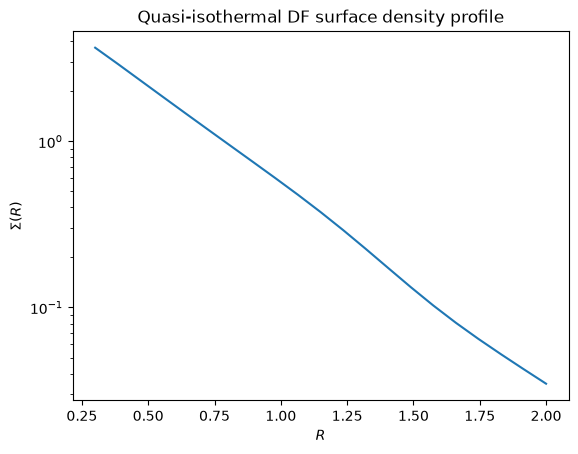

In [7]:
Rs = numpy.linspace(0.3, 2.0, 21)
smass = numpy.array([qdf.surfacemass_z(R) for R in Rs])
plt.semilogy(Rs, smass)
plt.xlabel(r"$R$")
plt.ylabel(r"$\Sigma(R)$")
plt.title("Quasi-isothermal DF surface density profile");

We can estimate the actual scale length from the DF by taking the log-slope:

In [8]:
# Estimate scale length from the DF near R=1
dR = 0.01
sm1 = qdf.surfacemass_z(1.0 - dR)
sm2 = qdf.surfacemass_z(1.0 + dR)
hR_est = -2.0 * dR / numpy.log(sm2 / sm1)
print(f"Estimated scale length: {hR_est:.3f} (input: {1.0 / 3.0:.3f})")

Estimated scale length: 0.372 (input: 0.333)


The actual scale length of the DF is close to, but not exactly equal to,
the input `hr` because the quasi-isothermal DF is only approximate.

## Velocity dispersion profiles

We can also compute the velocity dispersion profiles as a function of radius:

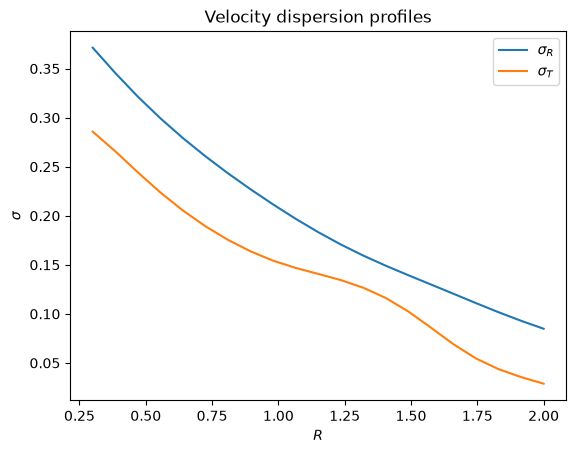

In [9]:
sigR2 = numpy.array([qdf.sigmaR2(R, 0.0) for R in Rs])
sigT2 = numpy.array([qdf.sigmaT2(R, 0.0) for R in Rs])
plt.plot(Rs, numpy.sqrt(sigR2), label=r"$\sigma_R$")
plt.plot(Rs, numpy.sqrt(sigT2), label=r"$\sigma_T$")
plt.xlabel(r"$R$")
plt.ylabel(r"$\sigma$")
plt.legend()
plt.title("Velocity dispersion profiles");

## Estimating scale lengths

We can estimate the actual scale lengths of the DF (which differ slightly from
the input parameters):

In [10]:
print("Estimated radial scale length hr:", qdf.estimate_hr(1.0), "(input: 0.333)")
print("Estimated sigma_R scale length hsr:", qdf.estimate_hsr(1.0), "(input: 1.0)")
print("Estimated sigma_z scale length hsz:", qdf.estimate_hsz(1.0), "(input: 1.0)")

Estimated radial scale length hr: 0.32908013715579104 (input: 0.333)
Estimated sigma_R scale length hsr: 1.191393519002444 (input: 1.0)
Estimated sigma_z scale length hsz: 1.0506910721558342 (input: 1.0)


## Mean velocities

Mean velocities can also be computed as a function of radius:

meanvR(1, 0): 0.0
meanvz(1, 0): 0.0
meanvT(1, 0): 0.9198834638078105


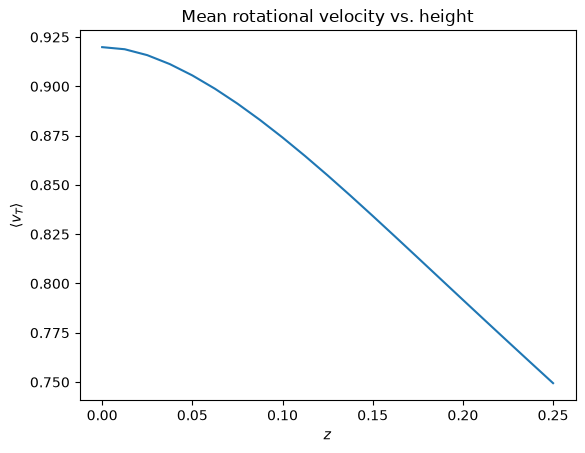

In [11]:
# Mean radial velocity is zero for an axisymmetric potential
print("meanvR(1, 0):", qdf.meanvR(1.0, 0.0))
# Mean vertical velocity is also zero
print("meanvz(1, 0):", qdf.meanvz(1.0, 0.0))
# Mean tangential velocity shows asymmetric drift
print("meanvT(1, 0):", qdf.meanvT(1.0, 0.0))

# meanvT decreases with height above the plane
zs = numpy.linspace(0.0, 0.25, 21)
mvts = numpy.array([qdf.meanvT(1.0, z) for z in zs])
plt.plot(zs, mvts)
plt.xlabel(r"$z$")
plt.ylabel(r"$\langle v_T \rangle$")
plt.title("Mean rotational velocity vs. height");

## Velocity ellipsoid tilt

The tilt of the velocity ellipsoid is zero when using the adiabatic approximation
(because it assumes decoupled planar and vertical motions). The Staeckel
approximation captures the coupling better:

In [12]:
from galpy.actionAngle import actionAngleStaeckel

# Staeckel-based action-angle calculator
aAS = actionAngleStaeckel(pot=MWPotential2014, delta=0.45, c=True)
qdfS = quasiisothermaldf(
    1.0 / 3.0,
    0.2,
    0.1,
    1.0,
    1.0,
    pot=MWPotential2014,
    aA=aAS,
    cutcounter=True,
)

# Tilt is zero for adiabatic approximation:
print("Tilt (adiabatic) at (1, 0.125):", qdf.tilt(1.0, 0.125), "rad")
# Non-zero for Staeckel:
print("Tilt (Staeckel) at (1, 0.125):", qdfS.tilt(1.0, 0.125), "rad")
print("  = {:.1f} degrees".format(qdfS.tilt(1.0, 0.125) * 180.0 / numpy.pi))

Tilt (adiabatic) at (1, 0.125): 0.0 rad
Tilt (Staeckel) at (1, 0.125): 0.10314272868452165 rad
  = 5.9 degrees


## Surface density radial profile

Compare the surface density from the adiabatic and Staeckel approximations
to a pure exponential:

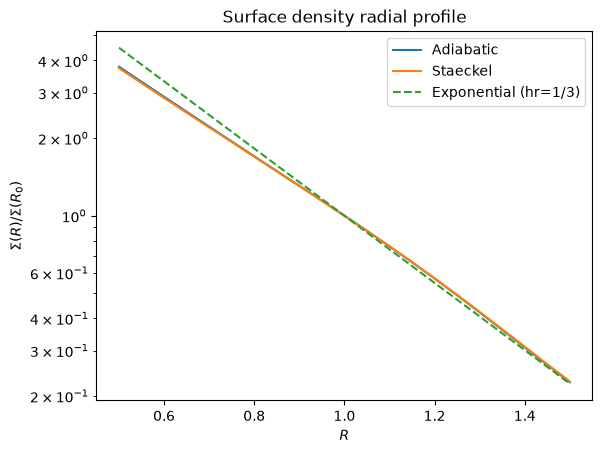

In [13]:
rs = numpy.linspace(0.5, 1.5, 21)
surfr = numpy.array([qdf.surfacemass_z(r) for r in rs])
surfrS = numpy.array([qdfS.surfacemass_z(r) for r in rs])
plt.semilogy(rs, surfr / surfr[10], label="Adiabatic")
plt.semilogy(rs, surfrS / surfrS[10], label="Staeckel")
plt.semilogy(
    rs, numpy.exp(-(rs - 1.0) / (1.0 / 3.0)), "--", label="Exponential (hr=1/3)"
)
plt.xlabel(r"$R$")
plt.ylabel(r"$\Sigma(R) / \Sigma(R_0)$")
plt.legend()
plt.title("Surface density radial profile");

## Marginalized velocity probabilities

The DF provides marginalized velocity probabilities `pvT`, `pvR`, `pvz`,
`pvRvT`, `pvRvz`, and `pvTvz`. These are multiplied by the density
(so marginalizing over remaining velocity components gives the density).

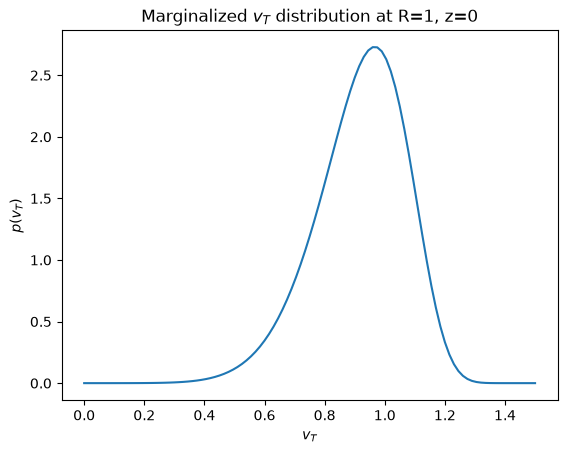

In [14]:
# Marginalized vT distribution at R=1, z=0
vts = numpy.linspace(0.0, 1.5, 101)
pvt = numpy.array([qdfS.pvT(vt, 1.0, 0.0) for vt in vts])
plt.plot(vts, pvt / numpy.sum(pvt) / (vts[1] - vts[0]))
plt.xlabel(r"$v_T$")
plt.ylabel(r"$p(v_T)$")
plt.title("Marginalized $v_T$ distribution at R=1, z=0");

## Sampling velocities

We can sample velocities at a given location using `sampleV`:

Optimization terminated successfully.
         Current function value: -6.244277
         Iterations: 1
         Function evaluations: 13


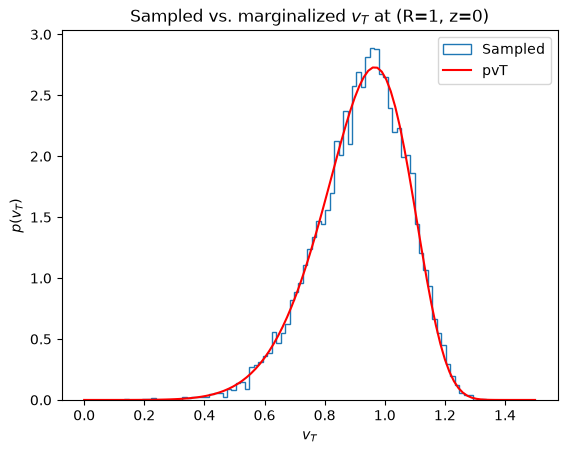

In [15]:
numpy.random.seed(1)
vs = qdfS.sampleV(1.0, 0.0, n=10000)
# Compare sampled vT distribution to the marginalized pvT
plt.hist(
    vs[:, 1], density=True, histtype="step", bins=101, range=[0.0, 1.5], label="Sampled"
)
plt.plot(vts, pvt / numpy.sum(pvt) / (vts[1] - vts[0]), "r-", label="pvT")
plt.xlabel(r"$v_T$")
plt.ylabel(r"$p(v_T)$")
plt.legend()
plt.title("Sampled vs. marginalized $v_T$ at (R=1, z=0)");